# 📄 Resume Classification using Transformer Models

## Project Overview
This project implements an end-to-end **Resume Classification System** that automatically categorizes resumes into professional domains using state-of-the-art Natural Language Processing techniques. The system leverages transformer-based deep learning models to understand the semantic content of resumes and classify them into relevant job categories.

## Problem Statement
Manual screening of resumes is time-consuming and prone to human bias. This project automates the classification process, enabling efficient talent acquisition by categorizing resumes into domains such as IT, Healthcare, Finance, Engineering, and more.

## Dataset
- **Primary Source:** Kaggle Resume Dataset
- **Supplementary Source:** Web-scraped resumes from PostJobFree
- **Categories:** 25+ professional domains

## Methodology
1. **Data Collection:** Combining Kaggle dataset with web-scraped data for comprehensive coverage
2. **Data Preprocessing:** Text cleaning, lemmatization, stopword removal, and domain-specific artifact filtering
3. **Feature Engineering:** Tokenization using transformer-specific tokenizers
4. **Model Training:** Fine-tuning pre-trained transformer models with early stopping and regularization
5. **Evaluation:** Comprehensive metrics including accuracy, F1-scores, and confusion matrices

## Models Implemented
| Model | Parameters | Architecture |
|-------|------------|--------------|
| **DistilBERT** | 66M | Distilled version of BERT, optimized for efficiency |
| **ELECTRA-Small** | 14M | Efficient pre-training with replaced token detection |
| **BERT-Base** | 110M | Bidirectional encoder representations from transformers |

## Key Features
- Multi-class classification across 25+ resume categories
- Transfer learning with pre-trained transformer models
- Regularization techniques (dropout, weight decay) to prevent overfitting
- Mixed-precision training for computational efficiency
- Comprehensive model comparison and analysis

---

**Author:**
Nirbhay Sharma 



In [ ]:
"""
Install required libraries and import essential modules for data collection,
web scraping, and data manipulation.
"""
!pip install -q transformers datasets torch scikit-learn beautifulsoup4 pandas requests kaggle

import pandas as pd
import requests
from bs4 import BeautifulSoup
import os
import time
import random
import numpy as np

print("Libraries installed and imported successfully.")

Libraries installed and imported successfully.


In [ ]:
"""
Mount Google Drive to access stored datasets and save model outputs.
"""
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


In [ ]:
"""
Load the Kaggle Resume dataset from Google Drive and prepare it for processing.
"""
base_path = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/Kaggle"
csv_path = os.path.join(base_path, "Resume.csv")

if os.path.exists(csv_path):
    print(f"Found file at: {csv_path}")
    
    df_kaggle = pd.read_csv(csv_path)
    df_kaggle['Source'] = 'Kaggle'
    df_kaggle = df_kaggle[['Resume_str', 'Category', 'Source']]
    
    print(f"✅ Loaded {len(df_kaggle)} resumes from Kaggle CSV.")
    display(df_kaggle.head(3))
else:
    print(f"❌ ERROR: File not found at {csv_path}")

Found file at: /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/Kaggle/Resume.csv
✅ Loaded 2484 resumes from Kaggle CSV.


,Resume_str,Category,Source
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,Kaggle
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,Kaggle
2,HR DIRECTOR Summary Over 2...,HR,Kaggle


In [ ]:
"""
Audit the PDF dataset to count files per category and identify categories
that need additional data collection through web scraping.
"""
import os
import pandas as pd
from google.colab import drive

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/Kaggle/PDF"

def audit_dataset(base_path):
    if not os.path.exists(base_path):
        print(f"❌ Error: Path not found: {base_path}")
        return None

    audit_data = []
    print(f"Scanning folders in: {base_path}...\n")

    categories = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]

    for category in sorted(categories):
        folder_path = os.path.join(base_path, category)
        files = [f for f in os.listdir(folder_path) if f.lower().endswith('.pdf')]
        count = len(files)
        samples = "; ".join(files[:3])

        audit_data.append({
            "Category": category,
            "File_Count": count,
            "Sample_Filenames": samples
        })
        print(f"   📂 {category:<25} : {count} files")

    df_audit = pd.DataFrame(audit_data)
    df_audit = df_audit.sort_values(by="File_Count", ascending=True)
    return df_audit

df_report = audit_dataset(BASE_PATH)

if df_report is not None:
    output_filename = "dataset_audit_report.csv"
    df_report.to_csv(output_filename, index=False)

    print("\n" + "="*40)
    print(f"✅ Audit Complete. Summary saved to '{output_filename}'")
    print("="*40)
    print("\nLOWEST COUNT CATEGORIES (Prioritize scraping these):")
    display(df_report.head(5))

    from google.colab import files
    files.download(output_filename)

Scanning folders in: /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/Kaggle/PDF...

   📂 ACCOUNTANT                : 118 files
   📂 ADVOCATE                  : 118 files
   📂 AGRICULTURE               : 63 files
   📂 APPAREL                   : 97 files
   📂 ARTS                      : 103 files
   📂 AUTOMOBILE                : 36 files
   📂 AVIATION                  : 117 files
   📂 BANKING                   : 115 files
   📂 BPO                       : 22 files
   📂 BUSINESS-DEVELOPMENT      : 120 files
   📂 CHEF                      : 118 files
   📂 CONSTRUCTION              : 112 files
   📂 CONSULTANT                : 115 files
   📂 DESIGNER                  : 107 files
   📂 DIGITAL-MEDIA             : 96 files
   📂 ENGINEERING               : 118 files
   📂 FINANCE                   : 118 files
   📂 FITNESS                   : 117 files
   📂 HEALTHCARE                : 115 files
   📂 HR                        : 110 files
   📂 INFORMATION-TECHNOLOGY    : 120 files
 

,Category,File_Count,Sample_Filenames
8,BPO,22,69097572.pdf; 16492045.pdf; 38707449.pdf
5,AUTOMOBILE,36,26341645.pdf; 18448085.pdf; 11152490.pdf
2,AGRICULTURE,63,11197262.pdf; 37292350.pdf; 54246169.pdf
14,DIGITAL-MEDIA,96,40311088.pdf; 58915642.pdf; 18900722.pdf
3,APPAREL,97,99806115.pdf; 41586420.pdf; 10562768.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
"""
Define web scraping logic to collect additional resume data from PostJobFree.
Implements search functionality and content extraction from resume pages.
"""
import requests
from bs4 import BeautifulSoup
import time
import random

BASE_URL = "https://www.postjobfree.com"

def get_links_from_search(query):
    """Search for a keyword and extract resume links from the result page."""
    search_url = f"{BASE_URL}/resumes?q={query}"
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

    links = set()
    try:
        response = requests.get(search_url, headers=headers, timeout=10)
        if response.status_code == 200:
            soup = BeautifulSoup(response.content, 'html.parser')
            for h3 in soup.find_all('h3'):
                a_tag = h3.find('a', href=True)
                if a_tag and '/resume/' in a_tag['href']:
                    links.add(BASE_URL + a_tag['href'])
    except Exception as e:
        print(f"   ⚠️ Search error for '{query}': {e}")
    return list(links)

def scrape_resume_content(url, category):
    """Visit a single resume link and extract the main text body."""
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}

    try:
        response = requests.get(url, headers=headers, timeout=8)
        if response.status_code != 200:
            return None

        soup = BeautifulSoup(response.content, 'html.parser')
        
        # Target the 'normalText' class which contains the resume content
        content_div = soup.find('div', class_='normalText')

        if content_div:
            text = content_div.get_text(separator="\n", strip=True)
            clean_lines = [line.strip() for line in text.split('\n') if line.strip()]
            clean_text = "\n".join(clean_lines)

            if len(clean_text) > 100:
                return {
                    'Text': clean_text,
                    'Label': category,
                    'Source': 'PostJobFree_Search'
                }

    except Exception as e:
        print(f"   ⚠️ Error processing {url}: {e}")
        return None
    return None

print("✅ Scraper Logic Updated (Targeting 'normalText').")

✅ Scraper Logic Updated (Targeting 'normalText').


In [ ]:
"""
Execute search-based web scraping to collect resumes for underrepresented categories.
Saves raw scraped data to Google Drive as a backup.
"""
import pandas as pd
import os

SEARCH_CONFIG = {
    "BPO": ["BPO", "Call Center Agent", "Customer Service Executive", "Telecaller", "Help Desk"],
    "AUTOMOBILE": ["Automobile Mechanic", "Car Technician", "Service Advisor", "Diesel Mechanic", "Auto Body"],
    "AGRICULTURE": ["Agriculture", "Farm Manager", "Agronomist", "Horticulture", "Landscaping"],
    "DIGITAL-MEDIA": ["Social Media Manager", "Content Writer", "Video Editor", "Blogger"],
    "APPAREL": ["Fashion Designer", "Merchandiser", "Textile Engineer", "Garment"]
}

scraped_data = []
print("🚀 Starting Search-Based Scraper...")

for category, queries in SEARCH_CONFIG.items():
    print(f"\n📂 Processing Category: {category}")

    category_links = set()
    for q in queries:
        print(f"   🔎 Searching: '{q}'...")
        links = get_links_from_search(q)
        category_links.update(links)
        time.sleep(1.5)

    print(f"   -> Found {len(category_links)} potential resumes. Scraping now...")

    count = 0
    target_limit = {"BPO": 45, "AUTOMOBILE": 40, "AGRICULTURE": 25, "DIGITAL-MEDIA": 15, "APPAREL": 15}

    for link in list(category_links):
        if count >= target_limit[category]:
            break

        data = scrape_resume_content(link, category)
        if data:
            scraped_data.append(data)
            count += 1
            print(f"      ✅ Scraped ({count}/{target_limit[category]})")
        else:
            print(f"      ❌ Failed to parse")

        time.sleep(random.uniform(1, 2))

df_scraped = pd.DataFrame(scraped_data)

if not df_scraped.empty:
    print("\n" + "="*30)
    print("✅ SCRAPING SUCCESS")
    print("="*30)
    print(df_scraped['Label'].value_counts())

    backup_path = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/scraped_raw_backup.csv"
    df_scraped.to_csv(backup_path, index=False)
    print(f"\n💾 SAFEGUARD: Raw scraped data saved to:\n   {backup_path}")

    if 'df_kaggle' in locals():
        df_final = pd.concat([df_kaggle, df_scraped], ignore_index=True)
        df_final = df_final.drop_duplicates(subset=['Text'])
        print("Merged with Kaggle data in memory.")
else:
    print("⚠️ No data collected. Connection might be blocked.")

🚀 Starting Search-Based Scraper...

📂 Processing Category: BPO
   🔎 Searching: 'BPO'...
   🔎 Searching: 'Call Center Agent'...
   🔎 Searching: 'Customer Service Executive'...
   🔎 Searching: 'Telecaller'...
   🔎 Searching: 'Help Desk'...
   -> Found 47 potential resumes. Scraping now...
      ✅ Scraped (1/45)
      ✅ Scraped (2/45)
      ✅ Scraped (3/45)
      ✅ Scraped (4/45)
      ✅ Scraped (5/45)
      ✅ Scraped (6/45)
      ✅ Scraped (7/45)
      ✅ Scraped (8/45)
      ✅ Scraped (9/45)
      ✅ Scraped (10/45)
      ✅ Scraped (11/45)
      ✅ Scraped (12/45)
      ✅ Scraped (13/45)
      ✅ Scraped (14/45)
      ✅ Scraped (15/45)
      ✅ Scraped (16/45)
      ✅ Scraped (17/45)
      ✅ Scraped (18/45)
      ✅ Scraped (19/45)
      ✅ Scraped (20/45)
      ✅ Scraped (21/45)
      ✅ Scraped (22/45)
      ✅ Scraped (23/45)
      ✅ Scraped (24/45)
      ✅ Scraped (25/45)
      ✅ Scraped (26/45)
      ✅ Scraped (27/45)
      ✅ Scraped (28/45)
      ✅ Scraped (29/45)
      ✅ Scraped (30/45)
 

In [ ]:
"""
Merge Kaggle and scraped data, then save individual resume files organized
by category into the final_data directory.
"""
OLD_PDF_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/Kaggle/PDF"
DATA_ROOT = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/"
FINAL_OUTPUT_DIR = os.path.join(DATA_ROOT, "final_data")

print(f"📍 Anchored to: {OLD_PDF_PATH}")
print(f"📂 Saving Final Data to: {FINAL_OUTPUT_DIR}")
print("\n🔄 Loading Data...")

if 'df_kaggle' in locals():
    print("   ✅ Using Kaggle data from memory.")
else:
    CSV_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/Kaggle/Resume.csv"
    df_kaggle = pd.read_csv(CSV_PATH)

dfs_to_merge = []

if not df_kaggle.empty:
    if 'Resume_str' in df_kaggle.columns:
        df_k = df_kaggle[['Resume_str', 'Category']].copy()
        df_k.columns = ['text', 'category']
        df_k['source'] = 'Kaggle'
        dfs_to_merge.append(df_k)

if 'df_scraped' in locals() and not df_scraped.empty:
    df_s = df_scraped[['Text', 'Label']].copy()
    df_s.columns = ['text', 'category']
    df_s['source'] = 'Scraped'
    dfs_to_merge.append(df_s)
    print(f"   ✅ Added {len(df_s)} scraped resumes.")
else:
    print("   ⚠️ No scraped data found in memory (df_scraped is missing).")

if dfs_to_merge:
    df_final = pd.concat(dfs_to_merge, ignore_index=True)
    df_final['category'] = df_final['category'].str.upper().str.strip()
    df_final = df_final.drop_duplicates(subset=['text'])
    print(f"   📊 Total Unique Resumes: {len(df_final)}")
else:
    print("❌ No data available to save.")
    df_final = pd.DataFrame()

if not df_final.empty:
    print(f"\n💾 Saving to {FINAL_OUTPUT_DIR}...")

    if not os.path.exists(FINAL_OUTPUT_DIR):
        os.makedirs(FINAL_OUTPUT_DIR)

    saved_count = 0

    for index, row in df_final.iterrows():
        cat = row['category']
        txt = row['text']
        src = row['source']

        cat_folder = os.path.join(FINAL_OUTPUT_DIR, cat)
        if not os.path.exists(cat_folder):
            os.makedirs(cat_folder)

        filename = f"{src}_{index}.txt"
        file_path = os.path.join(cat_folder, filename)

        try:
            with open(file_path, 'w', encoding='utf-8') as f:
                f.write(txt)
            saved_count += 1
        except Exception as e:
            print(f"Error saving {filename}: {e}")

    print("\n" + "="*40)
    print(f"🎉 SUCCESS! Saved {saved_count} resumes.")
    print(f"📂 Final Location: {FINAL_OUTPUT_DIR}")
    print("="*40)

📍 Anchored to: /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/Kaggle/PDF
📂 Saving Final Data to: /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/final_data

🔄 Loading Data...
   ✅ Using Kaggle data from memory.
   ✅ Added 140 scraped resumes.
   📊 Total Unique Resumes: 2617

💾 Saving to /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/final_data...

🎉 SUCCESS! Saved 2617 resumes.
📂 Final Location: /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/final_data


In [ ]:
"""
Perform data integrity check by comparing source PDF counts with final text file counts
to ensure no data loss during the processing pipeline.
"""
import os
import pandas as pd

SOURCE_PDF_DIR = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/Kaggle/PDF"
FINAL_TXT_DIR = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/final_data"

def get_folder_counts(root_path, file_extension):
    """Scan a directory and return a dictionary of {Category_Name: File_Count}."""
    counts = {}
    if not os.path.exists(root_path):
        return counts

    categories = [d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))]

    for cat in categories:
        cat_path = os.path.join(root_path, cat)
        files = [f for f in os.listdir(cat_path) if f.lower().endswith(file_extension)]
        counts[cat] = len(files)

    return counts

print(f"🔄 Scanning Source PDFs at: {SOURCE_PDF_DIR}...")
source_counts = get_folder_counts(SOURCE_PDF_DIR, '.pdf')

print(f"🔄 Scanning Final Text Files at: {FINAL_TXT_DIR}...")
final_counts = get_folder_counts(FINAL_TXT_DIR, '.txt')

all_categories = sorted(set(source_counts.keys()) | set(final_counts.keys()))
integrity_data = []

for cat in all_categories:
    pdf_count = source_counts.get(cat, 0)
    txt_count = final_counts.get(cat, 0)
    diff = txt_count - pdf_count

    if pdf_count == 0 and txt_count > 0:
        status = "🆕 NEW (From CSV/Scraped)"
    elif diff > 0:
        status = f"🚀 INCREASED (+{diff})"
    elif diff == 0:
        status = "✅ EXACT MATCH"
    elif diff > -5:
        status = "✅ OK (Deduped)"
    else:
        status = "⚠️ DATA LOSS"

    integrity_data.append({
        "Category": cat,
        "Old_PDF_Count": pdf_count,
        "New_TXT_Count": txt_count,
        "Status": status
    })

df_integrity = pd.DataFrame(integrity_data)

if not df_integrity.empty:
    print("\n" + "="*40)
    print("📊 DYNAMIC INTEGRITY CHECK REPORT")
    print("="*40)
    print(df_integrity.to_string(index=False))

    total_files = df_integrity['New_TXT_Count'].sum()
    print(f"\n✅ Total Resumes in Final Folder: {total_files}")

    if df_integrity['New_TXT_Count'].min() == 0:
        print("⚠️ WARNING: Some categories are empty!")
    else:
        print("✅ SUCCESS: All categories have data.")
else:
    print("❌ Error: No categories found in either Source or Destination.")

🔄 Scanning Source PDFs at: /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/Kaggle/PDF...
🔄 Scanning Final Text Files at: /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/final_data...

📊 DYNAMIC INTEGRITY CHECK REPORT
              Category  Old_PDF_Count  New_TXT_Count            Status
            ACCOUNTANT            118            118     ✅ EXACT MATCH
              ADVOCATE            118            118     ✅ EXACT MATCH
           AGRICULTURE             63             87 🚀 INCREASED (+24)
               APPAREL             97            112 🚀 INCREASED (+15)
                  ARTS            103            103     ✅ EXACT MATCH
            AUTOMOBILE             36             73 🚀 INCREASED (+37)
              AVIATION            117            116    ✅ OK (Deduped)
               BANKING            115            115     ✅ EXACT MATCH
                   BPO             22             67 🚀 INCREASED (+45)
  BUSINESS-DEVELOPMENT            120  

# Data Preprocessing

In [ ]:
"""
Import NLP preprocessing libraries and initialize NLTK resources
for text cleaning and normalization.
"""
import os
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
"""
Load all resume text files from the final_data directory into a DataFrame
with category labels.
"""
def load_resumes_to_df(root_path):
    """Recursively load all .txt files from category subfolders into a DataFrame."""
    data = []

    if not os.path.exists(root_path):
        print(f"Path not found: {root_path}")
        return pd.DataFrame()

    categories = [d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))]

    for category in categories:
        cat_path = os.path.join(root_path, category)
        files = [f for f in os.listdir(cat_path) if f.endswith('.txt')]

        for file in files:
            file_path = os.path.join(cat_path, file)
            try:
                with open(file_path, 'r', encoding='utf-8') as f:
                    text = f.read()
                    data.append({'Category': category, 'text': text})
            except Exception as e:
                print(f"Error reading {file}: {e}")

    return pd.DataFrame(data)

FINAL_TXT_DIR = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/final_data"
df = load_resumes_to_df(FINAL_TXT_DIR)

In [ ]:
"""
Define general text preprocessing: lowercase conversion, URL/mention removal,
special character cleaning, stopword removal, and lemmatization.
"""
def general_preprocessing(text):
    """Apply standard NLP preprocessing pipeline to input text."""
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    tokens = text.split()
    filtered_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return " ".join(filtered_tokens)

In [ ]:
"""Apply general preprocessing to all resume texts."""
df['cleaned_text'] = df['text'].apply(general_preprocessing)

In [ ]:
"""
Define domain-specific preprocessing to remove resume artifacts like headers,
contact information placeholders, and common non-informative terms.
"""
def fine_tuned_preprocessing(text):
    """Remove resume-specific artifacts that don't contribute to classification."""
    # These terms appear in resumes but don't help distinguish job categories
    artifacts_to_remove = [
        "resume", "curriculum", "vitae", "cv", "biodata", "profile",
        "page", "sheet", "document", "scanned", "copyright",
        "declaration", "hereby", "declare", "certified", "true",
        "mobile", "phone", "cell", "email", "gmail", "address", "residence",
        "permanent", "current", "location", "contact", "ref", "reference"
    ]

    tokens = text.split()
    cleaned_tokens = [word for word in tokens if word not in artifacts_to_remove]

    return " ".join(cleaned_tokens)

In [ ]:
"""Apply fine-tuned preprocessing to remove resume-specific artifacts."""
df['cleaned_text'] = df['cleaned_text'].apply(fine_tuned_preprocessing)

### Null handling created post preprocessing


In [ ]:
"""
Remove rows where preprocessing resulted in empty or whitespace-only text.
"""
def remove_empty_rows(df, text_col='cleaned_text'):
    """Drop rows with empty text after preprocessing."""
    initial_count = len(df)

    df[text_col] = df[text_col].replace(r'^\s*$', float('nan'), regex=True)
    df.dropna(subset=[text_col], inplace=True)

    final_count = len(df)
    dropped_count = initial_count - final_count

    if dropped_count > 0:
        print(f"Dropped {dropped_count} rows that became empty after preprocessing.")

    return df.reset_index(drop=True)

df = remove_empty_rows(df)

## Label Encoding

In [ ]:
"""
Encode categorical labels to integers using sklearn's LabelEncoder.
"""
from sklearn.preprocessing import LabelEncoder

def encode_target_variable(df, target_col='Category'):
    """Convert text category labels to numeric values."""
    le = LabelEncoder()
    df['Category_Label'] = le.fit_transform(df[target_col])
    category_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    return df, category_mapping

df, category_map = encode_target_variable(df)

In [ ]:
"""
Save the processed DataFrame to CSV for persistence and reuse.
"""
def save_processed_data(df, save_path):
    """Export processed data to CSV format."""
    df.to_csv(save_path, index=False)
    print(f"Data saved successfully to {save_path}")

PROCESSED_DATA_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/processed_resume_data.csv"
save_processed_data(df, PROCESSED_DATA_PATH)

Data saved successfully to /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/processed_resume_data.csv


In [ ]:
"""
Encode labels and save the category-to-integer mapping as JSON for inference.
"""
import json
from sklearn.preprocessing import LabelEncoder

def encode_and_save_mapping(df, target_col='Category', save_path=None):
    """Encode labels and persist the mapping dictionary."""
    le = LabelEncoder()
    df['Category_Label'] = le.fit_transform(df[target_col])
    category_map = dict(zip(le.classes_, le.transform(le.classes_)))

    if save_path:
        clean_mapping = {k: int(v) for k, v in category_map.items()}
        with open(save_path, 'w') as f:
            json.dump(clean_mapping, f)
        print(f"Category mapping saved successfully to {save_path}")

    return df, category_map

MAPPING_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/category_mapping.json"
df, category_map = encode_and_save_mapping(df, save_path=MAPPING_PATH)

Category mapping saved successfully to /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/category_mapping.json


In [ ]:
"""
Split data into train (80%), validation (10%), and test (10%) sets
using stratified sampling to maintain class distribution.
"""
from sklearn.model_selection import train_test_split

def standard_data_split(df):
    """Create stratified train/validation/test splits."""
    train_df, temp_df = train_test_split(
        df,
        test_size=0.20,
        random_state=42,
        stratify=df['Category_Label']
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        random_state=42,
        stratify=temp_df['Category_Label']
    )

    print(f"Train Set:      {len(train_df)}")
    print(f"Validation Set: {len(val_df)}")
    print(f"Test Set:       {len(test_df)}")

    return train_df, val_df, test_df

train_df, val_df, test_df = standard_data_split(df)

Train Set:      2093
Validation Set: 262
Test Set:       262


In [ ]:
"""
Initialize DistilBERT tokenizer and set hyperparameters for tokenization.
"""
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

MAX_LEN = 512
BATCH_SIZE = 16

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [ ]:
"""
Install deep learning libraries and set up the training environment
with GPU support for transformer model training.
"""
!pip install transformers datasets torch scikit-learn pandas tqdm seaborn matplotlib

from google.colab import drive
import os
import torch
import pandas as pd
import json
import numpy as np
import time
import copy
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data"
PROCESSED_DATA_PATH = os.path.join(BASE_PATH, "processed_resume_data.csv")
MAPPING_PATH = os.path.join(BASE_PATH, "category_mapping.json")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device set to: {device}")

Mounted at /content/drive
🚀 Device set to: cuda


## Switching to GPU


In [ ]:
"""
Setup environment for Model 1 (DistilBERT) training with necessary imports
and GPU configuration.
"""
!pip install transformers datasets torch scikit-learn pandas

from google.colab import drive
import os
import pandas as pd
import json
import torch
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data"
PROCESSED_DATA_PATH = os.path.join(BASE_PATH, "processed_resume_data.csv")
MAPPING_PATH = os.path.join(BASE_PATH, "category_mapping.json")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device set to: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Device set to: cpu


In [ ]:
"""
Load processed data and category mapping, then recreate train/val/test splits
with reproducible random state.
"""
if os.path.exists(PROCESSED_DATA_PATH):
    df = pd.read_csv(PROCESSED_DATA_PATH)
    print(f"✅ Loaded {len(df)} rows from {PROCESSED_DATA_PATH}")
else:
    raise FileNotFoundError("Processed data not found! Please check the path.")

if os.path.exists(MAPPING_PATH):
    with open(MAPPING_PATH, 'r') as f:
        category_map = json.load(f)
    print("✅ Category mapping loaded.")
else:
    raise FileNotFoundError("Category mapping not found! Cannot reconstruct labels.")

if 'Category_Label' not in df.columns:
    print("⚠️ 'Category_Label' column missing in CSV. Reconstructing from mapping...")

    if 'Category' in df.columns:
        cat_col = 'Category'
    elif 'category' in df.columns:
        cat_col = 'category'
    else:
        print(f"Columns found: {df.columns.tolist()}")
        raise KeyError("Could not find a 'Category' column to map labels to.")

    df['Category_Label'] = df[cat_col].map(category_map)

    if df['Category_Label'].isnull().any():
        print(f"⚠️ Dropping {df['Category_Label'].isnull().sum()} rows with unknown categories.")
        df = df.dropna(subset=['Category_Label'])
        df['Category_Label'] = df['Category_Label'].astype(int)
    print("✅ 'Category_Label' successfully reconstructed.")

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['Category_Label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['Category_Label']
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

✅ Loaded 2617 rows from /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/processed_resume_data.csv
✅ Category mapping loaded.
⚠️ 'Category_Label' column missing in CSV. Reconstructing from mapping...
✅ 'Category_Label' successfully reconstructed.
Train: 2093 | Val: 262 | Test: 262


In [ ]:
"""
Define custom PyTorch Dataset class for resume data and create DataLoaders
for efficient batch processing during training.
"""
from transformers import DistilBertTokenizer
from torch.utils.data import Dataset, DataLoader
import torch

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

MAX_LEN = 512
BATCH_SIZE = 16

class ResumeDataset(Dataset):
    """Custom Dataset for tokenizing and batching resume text data."""
    
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.text = dataframe['cleaned_text']
        self.targets = dataframe['Category_Label']

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        text = str(self.text.iloc[index])
        target = self.targets.iloc[index]

        inputs = self.tokenizer.encode_plus(
            text,
            None,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            return_token_type_ids=False,
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'ids': inputs['input_ids'].flatten(),
            'mask': inputs['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long)
        }

print("Creating DataLoaders...")
train_set = ResumeDataset(train_df, tokenizer, MAX_LEN)
val_set = ResumeDataset(val_df, tokenizer, MAX_LEN)
test_set = ResumeDataset(test_df, tokenizer, MAX_LEN)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("✅ DataLoaders ready.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Creating DataLoaders...
✅ DataLoaders ready.


In [ ]:
"""
Configure and train DistilBERT model with increased dropout for regularization,
linear learning rate scheduler with warmup, and early stopping.
"""
from transformers import DistilBertForSequenceClassification, get_linear_schedule_with_warmup, DistilBertConfig
from torch.optim import AdamW
import torch
import copy
import time
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

num_classes = len(category_map)
print(f"Initializing DistilBert with {num_classes} labels and 20% Dropout...")

# Higher dropout helps prevent overfitting on smaller datasets
config = DistilBertConfig.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_classes,
    dropout=0.2,
    attention_dropout=0.2
)

model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    config=config
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

EPOCHS = 20
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)

loss_fn = torch.nn.CrossEntropyLoss()


def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler):
    """Train model for one epoch and return accuracy and loss."""
    model.train()
    correct_predictions = 0
    n_examples = 0
    total_loss = 0

    progress_bar = tqdm(data_loader, desc="Training", unit="batch")

    for batch in progress_bar:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        targets = batch['targets'].to(device)

        outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
        loss = outputs.loss
        logits = outputs.logits

        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == targets)
        n_examples += targets.size(0)
        total_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        progress_bar.set_postfix(loss=loss.item())

    return correct_predictions.double() / n_examples, total_loss / len(data_loader)


def eval_model(model, data_loader, loss_fn, device):
    """Evaluate model on validation data and return accuracy and loss."""
    model.eval()
    correct_predictions = 0
    n_examples = 0
    total_loss = 0

    with torch.no_grad():
        for batch in data_loader:
            ids = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            targets = batch['targets'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
            loss = outputs.loss
            logits = outputs.logits

            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == targets)
            n_examples += targets.size(0)
            total_loss += loss.item()

    return correct_predictions.double() / n_examples, total_loss / len(data_loader)


patience = 4
patience_counter = 0
best_val_acc = 0
best_model_state = None

print(f"\n🚀 Starting Regularized Training...\n")

for epoch in range(EPOCHS):
    start_time = time.time()

    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_acc, train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device, scheduler)
    val_acc, val_loss = eval_model(model, val_loader, loss_fn, device)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    print(f"Time: {int(epoch_mins)}m {int(epoch_secs)}s")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        print(f"✅ Validation Improved ({best_val_acc:.4f} --> {val_acc:.4f}). Saving model state...")
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"⚠️ No improvement. Patience: {patience_counter}/{patience}")

    print("-" * 40)

    if patience_counter >= patience:
        print(f"\n🛑 Early stopping triggered!")
        model.load_state_dict(best_model_state)
        break

print("\nTraining Complete.")

Training on: cuda
Initializing DistilBert with 24 labels and 20% Dropout...


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Starting Regularized Training...

Epoch 1/20


Training: 100%|██████████| 131/131 [03:02<00:00,  1.39s/batch, loss=3.16]


...

Time: 2m 17s
Train Loss: 0.1396 | Train Acc: 0.9752
Val Loss:   0.5990 | Val Acc:   0.8664
⚠️ No improvement. Patience: 2/4
----------------------------------------
Epoch 14/20


Training: 100%|██████████| 131/131 [02:07<00:00,  1.03batch/s, loss=0.0765]


Time: 2m 14s
Train Loss: 0.1299 | Train Acc: 0.9771
Val Loss:   0.6224 | Val Acc:   0.8664
⚠️ No improvement. Patience: 3/4
----------------------------------------
Epoch 15/20


Training: 100%|██████████| 131/131 [02:07<00:00,  1.03batch/s, loss=0.179]


Time: 2m 14s
Train Loss: 0.1044 | Train Acc: 0.9842
Val Loss:   0.6419 | Val Acc:   0.8702
⚠️ No improvement. Patience: 4/4
----------------------------------------

🛑 Early stopping triggered!

Training Complete.


In [ ]:
"""
Save the trained DistilBERT model, tokenizer, and category mapping
in Hugging Face standard format for easy loading.
"""
import os
import json

SAVE_PATH = os.path.join(BASE_PATH, "saved_models", "distilbert_resume_classifier")
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

print(f"💾 Saving DistilBERT to {SAVE_PATH}...")

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

with open(os.path.join(SAVE_PATH, "category_mapping.json"), 'w') as f:
    json.dump(category_map, f)

print("✅ Saved successfully (Standard Format).")

💾 Saving DistilBERT to /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/saved_models/distilbert_resume_classifier...
✅ Saved successfully (Standard Format).


In [ ]:
"""
Load saved DistilBERT model for inference and recreate DataLoaders
for evaluation on validation and test sets.
"""
import os
import torch
import json
import pandas as pd
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data"
SAVE_PATH = os.path.join(BASE_PATH, "saved_models", "distilbert_resume_classifier")
PROCESSED_DATA_PATH = os.path.join(BASE_PATH, "processed_resume_data.csv")
BATCH_SIZE = 16
MAX_LEN = 512
device = torch.device("cpu")

print(f"🔄 Loading DistilBERT from: {SAVE_PATH}")

with open(os.path.join(SAVE_PATH, "category_mapping.json"), 'r') as f:
    category_map = json.load(f)

tokenizer = DistilBertTokenizer.from_pretrained(SAVE_PATH)
model = DistilBertForSequenceClassification.from_pretrained(SAVE_PATH)
model.to(device)
model.eval()

if 'test_df' not in locals() or 'val_df' not in locals():
    print("⚠️ Reloading DataFrames...")
    df = pd.read_csv(PROCESSED_DATA_PATH)
    if 'Category_Label' not in df.columns:
        cat_col = 'Category' if 'Category' in df.columns else 'category'
        df['Category_Label'] = df[cat_col].map(category_map)
        df = df.dropna(subset=['Category_Label'])
        df['Category_Label'] = df['Category_Label'].astype(int)

    train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Category_Label'])
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['Category_Label'])


class ResumeDataset(Dataset):
    """Custom Dataset for tokenizing resume data."""
    
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.text = dataframe['cleaned_text']
        self.targets = dataframe['Category_Label']
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        text = str(self.text.iloc[index])
        target = self.targets.iloc[index]
        inputs = self.tokenizer.encode_plus(
            text, None, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt'
        )
        return {
            'ids': inputs['input_ids'].flatten(),
            'mask': inputs['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long)
        }


val_loader = DataLoader(ResumeDataset(val_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ResumeDataset(test_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)
loss_fn = torch.nn.CrossEntropyLoss()

print("✅ DistilBERT Loaded. Ready for Cell 6 & 7.")

🔄 Loading DistilBERT from: /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/saved_models/distilbert_resume_classifier
✅ DistilBERT Loaded. Ready for Cell 6 & 7.


📊 Generating DistilBERT Evaluation Report...


Predicting on CPU: 100%|██████████| 17/17 [06:33<00:00, 23.17s/it]



Classification Report:

                        precision    recall  f1-score   support

            ACCOUNTANT       0.92      1.00      0.96        12
              ADVOCATE       0.83      0.83      0.83        12
           AGRICULTURE       0.88      0.78      0.82         9
               APPAREL       0.71      0.91      0.80        11
                  ARTS       0.86      0.55      0.67        11
            AUTOMOBILE       0.50      0.29      0.36         7
              AVIATION       0.89      0.73      0.80        11
               BANKING       1.00      0.73      0.84        11
                   BPO       0.75      0.86      0.80         7
  BUSINESS-DEVELOPMENT       0.86      1.00      0.92        12
                  CHEF       0.85      0.92      0.88        12
          CONSTRUCTION       1.00      1.00      1.00        11
            CONSULTANT       1.00      0.91      0.95        11
              DESIGNER       0.85      1.00      0.92        11
         DIGIT

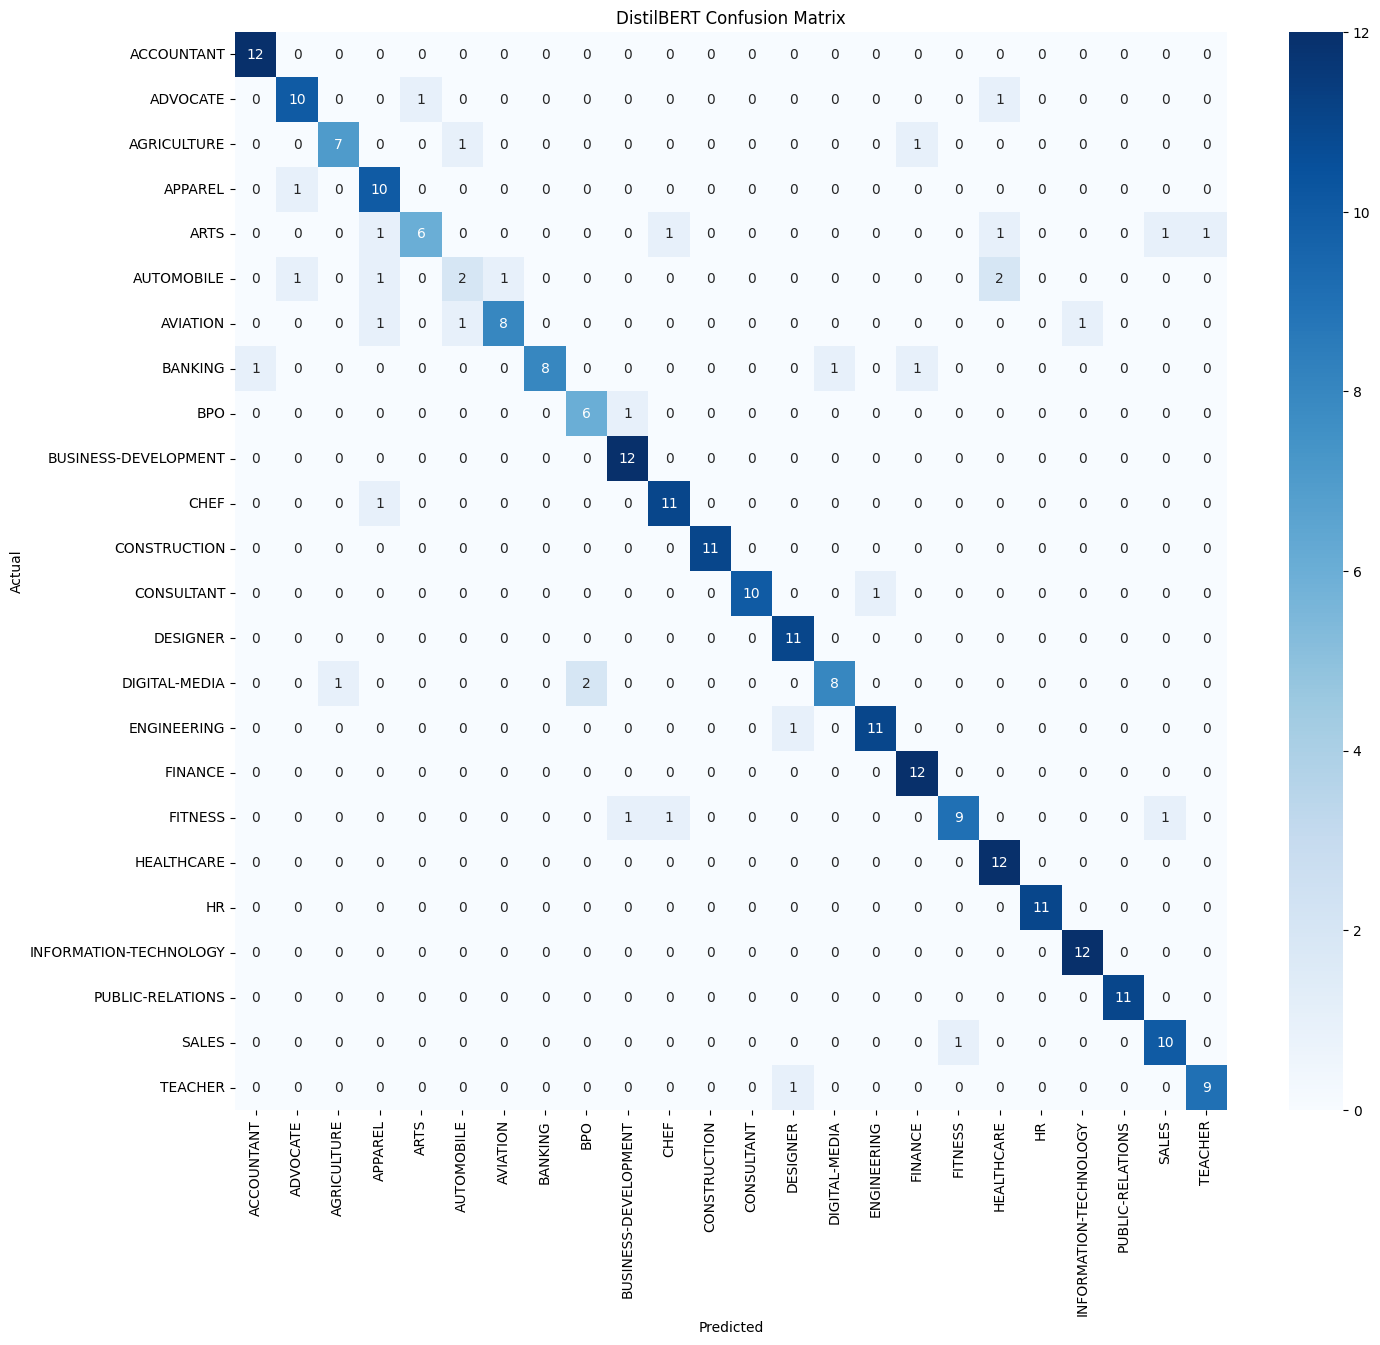

In [ ]:
"""
Generate predictions on validation set and display classification report
with confusion matrix heatmap for DistilBERT model evaluation.
"""
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

def get_predictions(model, data_loader, device):
    """Generate predictions for all samples in the data loader."""
    model.eval()
    predictions = []
    real_values = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Predicting on CPU"):
            ids = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            targets = batch['targets'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            real_values.extend(targets.cpu().numpy())

    return np.array(predictions), np.array(real_values)

print("📊 Generating DistilBERT Evaluation Report...")
y_pred, y_test = get_predictions(model, val_loader, device)

class_names = [k for k, v in sorted(category_map.items(), key=lambda item: item[1])]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('DistilBERT Confusion Matrix')
plt.show()

In [ ]:
"""
Evaluate DistilBERT model on the held-out test set and report final metrics.
"""
from tqdm import tqdm

print("🧪 Running DistilBERT Final Test Set Evaluation...")

model.eval()
test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    progress_bar = tqdm(test_loader, desc="Testing DistilBERT", unit="batch")

    for batch in progress_bar:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        targets = batch['targets'].to(device)

        outputs = model(input_ids=ids, attention_mask=mask, labels=targets)

        loss = outputs.loss
        logits = outputs.logits

        test_loss += loss.item()

        _, preds = torch.max(logits, dim=1)
        test_correct += torch.sum(preds == targets).item()
        test_total += targets.size(0)

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

distil_test_acc = test_correct / test_total
distil_test_loss = test_loss / len(test_loader)

test_acc = distil_test_acc
test_loss = distil_test_loss

print(f"\n" + "="*30)
print(f"FINAL DISTILBERT TEST RESULTS")
print(f"="*30)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"="*30)

🧪 Running DistilBERT Final Test Set Evaluation...


Testing DistilBERT: 100%|██████████| 17/17 [05:01<00:00, 17.74s/batch, loss=0.7876]


FINAL DISTILBERT TEST RESULTS
Test Loss: 0.6854
Test Accuracy: 0.8359


In [ ]:
"""
Define inference function and demonstrate predictions on sample test resumes.
"""
def predict_resume(text, model, tokenizer, device, category_map):
    """Predict the job category for a given resume text."""
    id_to_category = {v: k for k, v in category_map.items()}

    inputs = tokenizer.encode_plus(
        text,
        None,
        add_special_tokens=True,
        max_length=512,
        padding='max_length',
        return_token_type_ids=False,
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    ids = inputs['input_ids'].to(device)
    mask = inputs['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(ids, attention_mask=mask)
        _, prediction = torch.max(outputs.logits, dim=1)

    predicted_id = prediction.item()
    return id_to_category[predicted_id]

print("🤖 Inference function ready.")
print("Example Prediction on first 10 Test samples:")
for i in range(10):
    print(f"Testing for resume {test_df.index[i]}")
    sample_text = test_df['cleaned_text'].iloc[i]
    predicted_label = predict_resume(sample_text, model, tokenizer, device, category_map)
    actual_label = [k for k, v in category_map.items() if v == test_df['Category_Label'].iloc[i]][0]

    print(f"Actual: {actual_label}")
    print(f"Predicted: {predicted_label}")

🤖 Inference function ready.
Example Prediction on first 10 Test samples:
Testing for resume 465
Actual: ADVOCATE
Predicted: ADVOCATE
Testing for resume 165
Actual: DESIGNER
Predicted: DESIGNER
Testing for resume 651
Actual: BUSINESS-DEVELOPMENT
Predicted: BUSINESS-DEVELOPMENT
Testing for resume 968
Actual: AGRICULTURE
Predicted: SALES
Testing for resume 1224
Actual: CONSULTANT
Predicted: CONSULTANT
Testing for resume 2095
Actual: CONSTRUCTION
Predicted: CONSTRUCTION
Testing for resume 890
Actual: FITNESS
Predicted: DIGITAL-MEDIA
Testing for resume 2133
Actual: CONSTRUCTION
Predicted: CONSTRUCTION
Testing for resume 2385
Actual: BANKING
Predicted: BANKING
Testing for resume 2176
Actual: PUBLIC-RELATIONS
Predicted: PUBLIC-RELATIONS


In [ ]:
"""
Save detailed DistilBERT metrics including per-class F1 scores to JSON
for later comparison with other models.
"""
import os
import json
import pandas as pd
from sklearn.metrics import classification_report

MODEL_NAME = "DistilBERT"

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data"
METRICS_DIR = os.path.join(BASE_PATH, "detailed_model_metrics")

if not os.path.exists(METRICS_DIR):
    os.makedirs(METRICS_DIR)

print(f"💾 Saving DETAILED metrics for {MODEL_NAME}...")

required_vars = ['y_test', 'y_pred', 'test_acc', 'test_loss', 'category_map']
missing = [v for v in required_vars if v not in locals()]
if missing:
    print(f"❌ Error: Missing variables {missing}. Please run Cell 6 and Cell 7 first!")
else:
    class_names = [k for k, v in sorted(category_map.items(), key=lambda item: item[1])]

    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    final_data = {
        "model_name": MODEL_NAME,
        "test_results": {
            "accuracy": float(test_acc),
            "loss": float(test_loss)
        },
        "classification_report": report_dict,
        "parameters": "66M" if "Distil" in MODEL_NAME else ("110M" if "Base" in MODEL_NAME else "14M")
    }

    filename = f"{MODEL_NAME}_detailed_metrics.json"
    save_path = os.path.join(METRICS_DIR, filename)

    with open(save_path, 'w') as f:
        json.dump(final_data, f, indent=4)

    print(f"✅ Success! Detailed report saved to:")
    print(f"   📂 {save_path}")
    print(f"   📊 Contains: Test Acc ({test_acc:.4f}), Test Loss ({test_loss:.4f}), and F1-scores for {len(class_names)} categories.")

💾 Saving DETAILED metrics for DistilBERT...
✅ Success! Detailed report saved to:
   📂 /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/detailed_model_metrics/DistilBERT_detailed_metrics.json
   📊 Contains: Test Acc (0.8359), Test Loss (0.6854), and F1-scores for 24 categories.


## Model No. 2 Electra


In [ ]:
"""
Setup environment for Model 2 (ELECTRA-Small) training with GPU support.
"""
!pip install transformers datasets torch scikit-learn pandas tqdm seaborn matplotlib

from google.colab import drive
import os
import torch
import pandas as pd
import json
import numpy as np
import time
import copy
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data"
PROCESSED_DATA_PATH = os.path.join(BASE_PATH, "processed_resume_data.csv")
MAPPING_PATH = os.path.join(BASE_PATH, "category_mapping.json")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device set to: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Device set to: cpu


In [ ]:
"""
Load processed data for ELECTRA model and create train/val/test splits.
"""
if os.path.exists(PROCESSED_DATA_PATH):
    df = pd.read_csv(PROCESSED_DATA_PATH)
    print(f"✅ Loaded {len(df)} rows.")
else:
    raise FileNotFoundError("Processed data not found!")

if os.path.exists(MAPPING_PATH):
    with open(MAPPING_PATH, 'r') as f:
        category_map = json.load(f)
    print("✅ Mapping loaded.")

if 'Category_Label' not in df.columns:
    print("⚠️ Reconstructing 'Category_Label'...")
    cat_col = 'Category' if 'Category' in df.columns else 'category'
    df['Category_Label'] = df[cat_col].map(category_map)
    df = df.dropna(subset=['Category_Label'])
    df['Category_Label'] = df['Category_Label'].astype(int)

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Category_Label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['Category_Label'])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

✅ Loaded 2617 rows.
✅ Mapping loaded.
⚠️ Reconstructing 'Category_Label'...
Train: 2093 | Val: 262 | Test: 262


In [ ]:
"""
Initialize ELECTRA tokenizer and create DataLoaders with larger batch size
since ELECTRA-Small is more memory efficient.
"""
from transformers import ElectraTokenizer

tokenizer = ElectraTokenizer.from_pretrained('google/electra-small-discriminator')
MAX_LEN = 512
BATCH_SIZE = 32

print("Building ELECTRA DataLoaders...")
train_loader = DataLoader(ResumeDataset(train_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(ResumeDataset(val_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(ResumeDataset(test_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("✅ Ready.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

Building ELECTRA DataLoaders...
✅ Ready.


In [ ]:
"""
Configure and train ELECTRA-Small model with FP16 mixed precision
for faster training while maintaining accuracy.
"""
from transformers import ElectraForSequenceClassification, ElectraConfig

print(f"Initializing ELECTRA-Small...")
num_classes = len(category_map)
config = ElectraConfig.from_pretrained(
    'google/electra-small-discriminator',
    num_labels=num_classes,
    dropout=0.1,
    summary_last_dropout=0.1
)

model = ElectraForSequenceClassification.from_pretrained(
    'google/electra-small-discriminator',
    config=config
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=5e-5, weight_decay=0.01)

EPOCHS = 20
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
scaler = GradScaler()

patience = 4
patience_counter = 0
best_val_acc = 0
best_model_state = None

print(f"\n🚀 Starting ELECTRA Training...\n")

for epoch in range(EPOCHS):
    start_time = time.time()
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_acc, train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device, scheduler, scaler)
    val_acc, val_loss = eval_model(model, val_loader, loss_fn, device)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    print(f"Time: {int(epoch_mins)}m {int(epoch_secs)}s")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        print(f"✅ Improved ({best_val_acc:.4f} -> {val_acc:.4f}). Saving...")
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"⚠️ Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("🛑 Early stopping triggered.")
        model.load_state_dict(best_model_state)
        break

print("\nTraining Complete.")

Initializing ELECTRA-Small...


Some weights of ElectraForSequenceClassification were not initialized from the model checkpoint at google/electra-small-discriminator and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-3685228746.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # Use FP16 here too!



🚀 Starting ELECTRA Training...

Epoch 1/20


Training:   0%|          | 0/66 [00:00<?, ?batch/s]/tmp/ipython-input-4171341061.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Training: 100%|██████████| 66/66 [01:33<00:00,  1.42s/batch, loss=3.14]


Time: 1m 38s
Train Loss: 3.1691 | Train Acc: 0.0578
Val Loss:   3.1103 | Val Acc:   0.1489
✅ Improved (0.0000 -> 0.1489). Saving...
Epoch 2/20


...

Time: 0m 53s
Train Loss: 0.5295 | Train Acc: 0.9240
Val Loss:   0.7688 | Val Acc:   0.8397
⚠️ Patience: 2/4
Epoch 17/20


Training: 100%|██████████| 66/66 [00:49<00:00,  1.34batch/s, loss=1.55]


Time: 0m 57s
Train Loss: 0.5039 | Train Acc: 0.9279
Val Loss:   0.7637 | Val Acc:   0.8282
⚠️ Patience: 3/4
Epoch 18/20


Training: 100%|██████████| 66/66 [00:50<00:00,  1.30batch/s, loss=0.251]


Time: 0m 55s
Train Loss: 0.4736 | Train Acc: 0.9341
Val Loss:   0.7567 | Val Acc:   0.8359
⚠️ Patience: 4/4
🛑 Early stopping triggered.

Training Complete.


In [ ]:
"""
Save the trained ELECTRA model with tokenizer and category mapping.
"""
SAVE_PATH_ELECTRA = os.path.join(BASE_PATH, "saved_models", "electra_small_resume_classifier")
if not os.path.exists(SAVE_PATH_ELECTRA):
    os.makedirs(SAVE_PATH_ELECTRA)

print(f"💾 Saving ELECTRA to {SAVE_PATH_ELECTRA}...")
model.save_pretrained(SAVE_PATH_ELECTRA)
tokenizer.save_pretrained(SAVE_PATH_ELECTRA)
with open(os.path.join(SAVE_PATH_ELECTRA, "category_mapping.json"), 'w') as f:
    json.dump(category_map, f)
print("✅ Saved.")

💾 Saving ELECTRA to /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/saved_models/electra_small_resume_classifier...
✅ Saved.


In [ ]:
"""
Load saved ELECTRA model for inference and evaluation.
"""
import os
import torch
import json
from transformers import ElectraTokenizer, ElectraForSequenceClassification

SAVE_PATH_ELECTRA = os.path.join(BASE_PATH, "saved_models", "electra_small_resume_classifier")
device = torch.device("cpu")

print(f"🔄 Loading ELECTRA from: {SAVE_PATH_ELECTRA}")

tokenizer = ElectraTokenizer.from_pretrained(SAVE_PATH_ELECTRA)
model = ElectraForSequenceClassification.from_pretrained(SAVE_PATH_ELECTRA)
model.to(device)
model.eval()

val_loader = DataLoader(ResumeDataset(val_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ResumeDataset(test_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)

print("✅ ELECTRA Loaded. Ready for Cell 6 & 7.")

🔄 Loading ELECTRA from: /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/saved_models/electra_small_resume_classifier
✅ ELECTRA Loaded. Ready for Cell 6 & 7.


📊 Generating ELECTRA Evaluation Report...


Predicting on CPU: 100%|██████████| 17/17 [03:03<00:00, 10.79s/it]



Classification Report:

                        precision    recall  f1-score   support

            ACCOUNTANT       0.92      1.00      0.96        12
              ADVOCATE       0.90      0.75      0.82        12
           AGRICULTURE       0.50      0.67      0.57         9
               APPAREL       0.73      0.73      0.73        11
                  ARTS       0.86      0.55      0.67        11
            AUTOMOBILE       0.67      0.29      0.40         7
              AVIATION       0.82      0.82      0.82        11
               BANKING       0.90      0.82      0.86        11
                   BPO       0.75      0.43      0.55         7
  BUSINESS-DEVELOPMENT       0.86      1.00      0.92        12
                  CHEF       0.91      0.83      0.87        12
          CONSTRUCTION       1.00      1.00      1.00        11
            CONSULTANT       0.83      0.91      0.87        11
              DESIGNER       0.79      1.00      0.88        11
         DIGIT

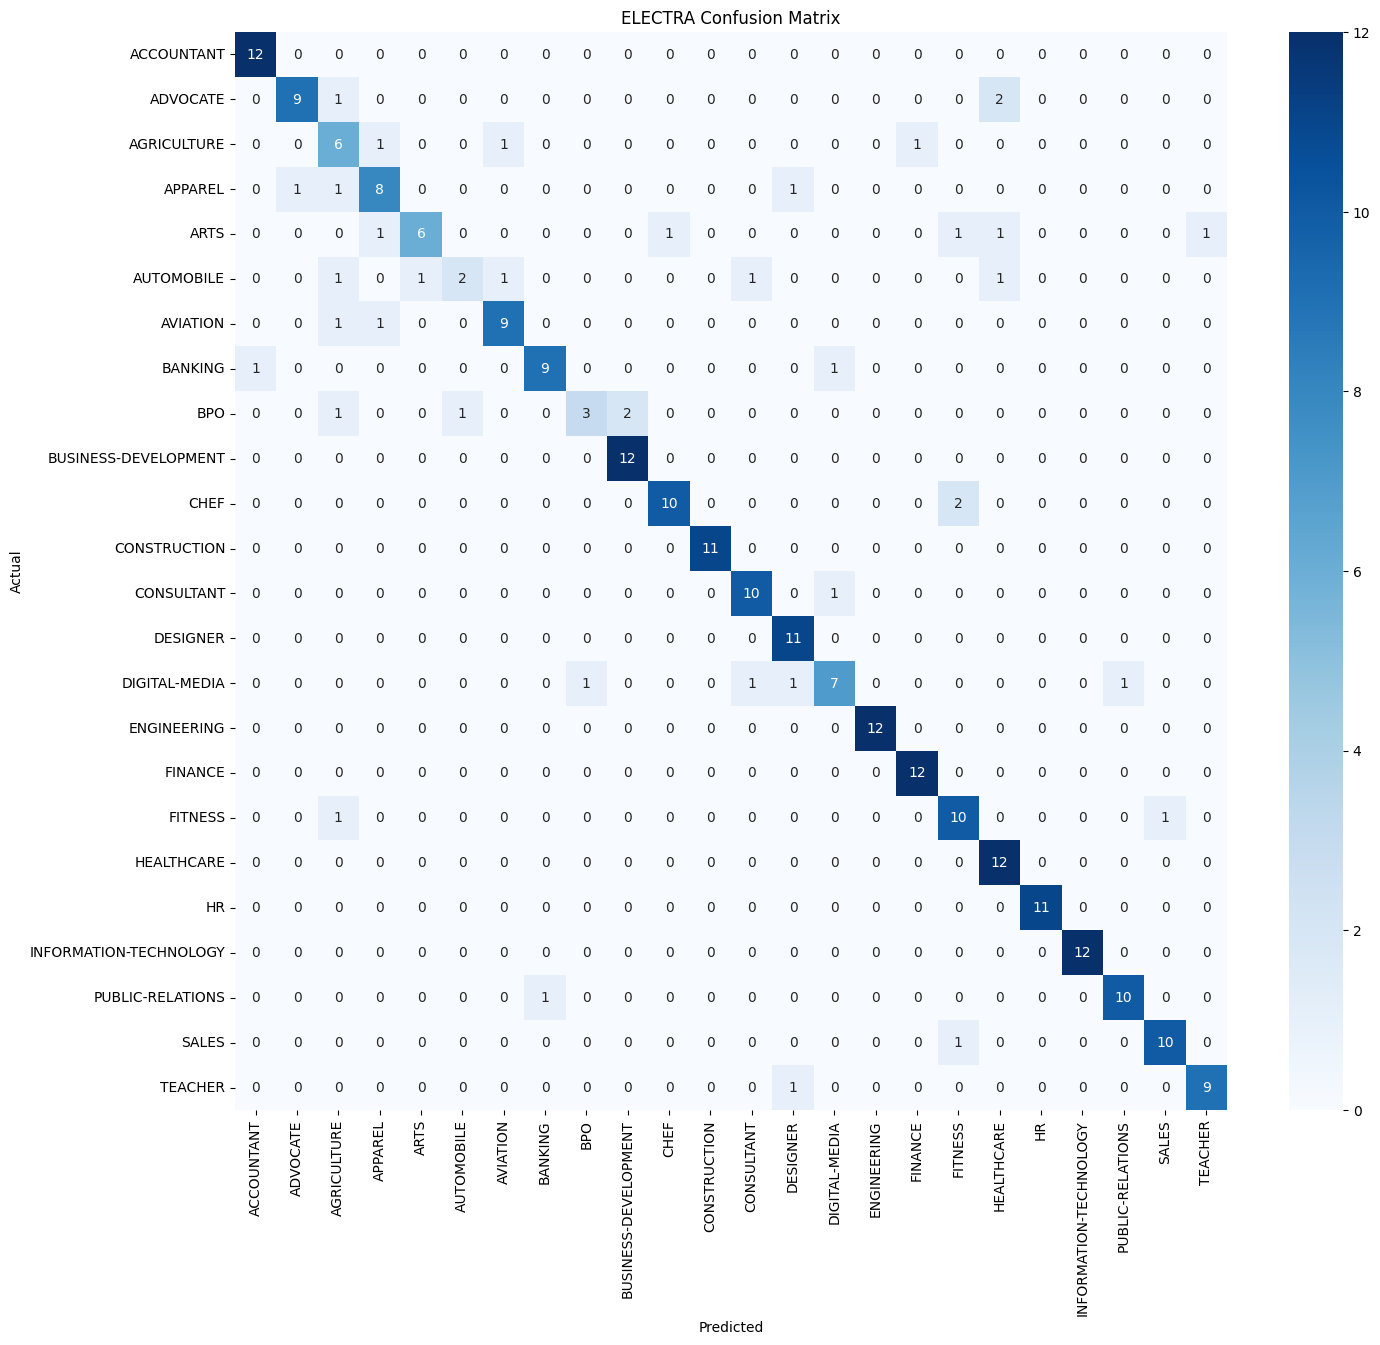

In [ ]:
"""
Generate ELECTRA evaluation report with classification metrics and confusion matrix.
"""
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def get_predictions(model, data_loader, device):
    """Generate predictions for all samples in the data loader."""
    model.eval()
    predictions = []
    real_values = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Predicting on CPU"):
            ids = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            targets = batch['targets'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            real_values.extend(targets.cpu().numpy())

    return np.array(predictions), np.array(real_values)

print("📊 Generating ELECTRA Evaluation Report...")
y_pred, y_test = get_predictions(model, val_loader, device)

class_names = [k for k, v in sorted(category_map.items(), key=lambda item: item[1])]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ELECTRA Confusion Matrix')
plt.show()

In [ ]:
"""
Evaluate ELECTRA model on the final test set and report metrics.
"""
from tqdm import tqdm

print("🧪 Running ELECTRA Final Test Set Evaluation...")

model.eval()
test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    progress_bar = tqdm(test_loader, desc="Testing ELECTRA", unit="batch")

    for batch in progress_bar:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        targets = batch['targets'].to(device)

        outputs = model(input_ids=ids, attention_mask=mask, labels=targets)

        loss = outputs.loss
        logits = outputs.logits

        test_loss += loss.item()

        _, preds = torch.max(logits, dim=1)
        test_correct += torch.sum(preds == targets).item()
        test_total += targets.size(0)

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

electra_test_acc = test_correct / test_total
electra_test_loss = test_loss / len(test_loader)

test_acc = electra_test_acc
test_loss = electra_test_loss

print(f"\n" + "="*30)
print(f"FINAL ELECTRA TEST RESULTS")
print(f"="*30)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"="*30)

🧪 Running ELECTRA Final Test Set Evaluation...


Testing ELECTRA: 100%|██████████| 17/17 [03:17<00:00, 11.59s/batch, loss=0.6730]


FINAL ELECTRA TEST RESULTS
Test Loss: 0.8582
Test Accuracy: 0.8206


In [ ]:
"""
Demonstrate ELECTRA inference on sample test resumes.
"""
def predict_resume(text, model, tokenizer, device, category_map):
    """Predict the job category for a given resume text."""
    id_to_category = {v: k for k, v in category_map.items()}

    inputs = tokenizer.encode_plus(
        text,
        None,
        add_special_tokens=True,
        max_length=512,
        padding='max_length',
        return_token_type_ids=False,
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    ids = inputs['input_ids'].to(device)
    mask = inputs['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(ids, attention_mask=mask)
        _, prediction = torch.max(outputs.logits, dim=1)

    predicted_id = prediction.item()
    return id_to_category[predicted_id]

print("🤖 BERT Inference ready.")
print("Example Prediction on first 10 Test samples:")
for i in range(10):
    print(f"Testing for resume {test_df.index[i]}")
    sample_text = test_df['cleaned_text'].iloc[i]
    predicted_label = predict_resume(sample_text, model, tokenizer, device, category_map)
    actual_label = [k for k, v in category_map.items() if v == test_df['Category_Label'].iloc[i]][0]

    print(f"Actual: {actual_label}")
    print(f"Predicted: {predicted_label}")

🤖 BERT Inference ready.
Example Prediction on first 10 Test samples:
Testing for resume 465
Actual: ADVOCATE
Predicted: ADVOCATE
Testing for resume 165
Actual: DESIGNER
Predicted: DESIGNER
Testing for resume 651
Actual: BUSINESS-DEVELOPMENT
Predicted: BUSINESS-DEVELOPMENT
Testing for resume 968
Actual: AGRICULTURE
Predicted: SALES
Testing for resume 1224
Actual: CONSULTANT
Predicted: CONSULTANT
Testing for resume 2095
Actual: CONSTRUCTION
Predicted: CONSTRUCTION
Testing for resume 890
Actual: FITNESS
Predicted: DIGITAL-MEDIA
Testing for resume 2133
Actual: CONSTRUCTION
Predicted: CONSTRUCTION
Testing for resume 2385
Actual: BANKING
Predicted: BANKING
Testing for resume 2176
Actual: PUBLIC-RELATIONS
Predicted: PUBLIC-RELATIONS


In [ ]:
"""
Save detailed ELECTRA-Small metrics to JSON for model comparison.
"""
import os
import json
import pandas as pd
from sklearn.metrics import classification_report

MODEL_NAME = "ELECTRA-Small"

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data"
METRICS_DIR = os.path.join(BASE_PATH, "detailed_model_metrics")

if not os.path.exists(METRICS_DIR):
    os.makedirs(METRICS_DIR)

print(f"💾 Saving DETAILED metrics for {MODEL_NAME}...")

required_vars = ['y_test', 'y_pred', 'test_acc', 'test_loss', 'category_map']
missing = [v for v in required_vars if v not in locals()]
if missing:
    print(f"❌ Error: Missing variables {missing}. Please run Cell 6 and Cell 7 first!")
else:
    class_names = [k for k, v in sorted(category_map.items(), key=lambda item: item[1])]

    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    final_data = {
        "model_name": MODEL_NAME,
        "test_results": {
            "accuracy": float(test_acc),
            "loss": float(test_loss)
        },
        "classification_report": report_dict,
        "parameters": "66M" if "Distil" in MODEL_NAME else ("110M" if "Base" in MODEL_NAME else "14M")
    }

    filename = f"{MODEL_NAME}_detailed_metrics.json"
    save_path = os.path.join(METRICS_DIR, filename)

    with open(save_path, 'w') as f:
        json.dump(final_data, f, indent=4)

    print(f"✅ Success! Detailed report saved to:")
    print(f"   📂 {save_path}")
    print(f"   📊 Contains: Test Acc ({test_acc:.4f}), Test Loss ({test_loss:.4f}), and F1-scores for {len(class_names)} categories.")

💾 Saving DETAILED metrics for ELECTRA-Small...
✅ Success! Detailed report saved to:
   📂 /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/detailed_model_metrics/ELECTRA-Small_detailed_metrics.json
   📊 Contains: Test Acc (0.8206), Test Loss (0.8582), and F1-scores for 24 categories.


## Model No. 3 BERT-Base

In [ ]:
"""
Setup environment for Model 3 (BERT-Base) training with GPU support.
"""
!pip install transformers datasets torch scikit-learn pandas tqdm seaborn matplotlib

from google.colab import drive
import os
import torch
import pandas as pd
import json
import numpy as np
import time
import copy
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

drive.mount('/content/drive')

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data"
PROCESSED_DATA_PATH = os.path.join(BASE_PATH, "processed_resume_data.csv")
MAPPING_PATH = os.path.join(BASE_PATH, "category_mapping.json")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device set to: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Device set to: cpu


In [ ]:
"""
Load processed data for BERT-Base model and create train/val/test splits.
"""
if os.path.exists(PROCESSED_DATA_PATH):
    df = pd.read_csv(PROCESSED_DATA_PATH)
    print(f"✅ Loaded {len(df)} rows.")
else:
    raise FileNotFoundError("Processed data not found!")

if os.path.exists(MAPPING_PATH):
    with open(MAPPING_PATH, 'r') as f:
        category_map = json.load(f)
    print("✅ Mapping loaded.")

if 'Category_Label' not in df.columns:
    print("⚠️ Reconstructing 'Category_Label'...")
    cat_col = 'Category' if 'Category' in df.columns else 'category'
    df['Category_Label'] = df[cat_col].map(category_map)
    df = df.dropna(subset=['Category_Label'])
    df['Category_Label'] = df['Category_Label'].astype(int)

train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Category_Label'])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['Category_Label'])

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

✅ Loaded 2617 rows.
✅ Mapping loaded.
⚠️ Reconstructing 'Category_Label'...
Train: 2093 | Val: 262 | Test: 262


In [ ]:
"""
Initialize BERT tokenizer and create DataLoaders with smaller batch size
due to BERT-Base's larger memory footprint.
"""
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
MAX_LEN = 512
BATCH_SIZE = 8


class ResumeDataset(Dataset):
    """Custom Dataset for tokenizing resume data with BERT tokenizer."""
    
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.text = dataframe['cleaned_text']
        self.targets = dataframe['Category_Label']

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        text = str(self.text.iloc[index])
        target = self.targets.iloc[index]
        inputs = self.tokenizer.encode_plus(
            text, None, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt'
        )
        return {
            'ids': inputs['input_ids'].flatten(),
            'mask': inputs['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long)
        }


print("Building BERT DataLoaders...")
train_loader = DataLoader(ResumeDataset(train_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(ResumeDataset(val_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(ResumeDataset(test_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("✅ Ready.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Building BERT DataLoaders...
✅ Ready.


In [ ]:
"""
Configure and train BERT-Base model with regularization, FP16 mixed precision,
learning rate warmup, and early stopping for optimal performance.
"""
from transformers import BertForSequenceClassification, BertConfig, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
import torch
import copy
import time
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Training BERT-Base on: {device}")

num_classes = len(category_map)
print(f"Initializing BERT-Base with {num_classes} labels and 20% Dropout...")

config = BertConfig.from_pretrained(
    'bert-base-uncased',
    num_labels=num_classes,
    dropout=0.2,
    attention_probs_dropout_prob=0.2
)

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    config=config
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

EPOCHS = 20
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * 0.1),
    num_training_steps=total_steps
)

loss_fn = torch.nn.CrossEntropyLoss()
scaler = GradScaler()


def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, scaler):
    """Train model for one epoch with mixed precision."""
    model.train()
    correct_predictions = 0
    n_examples = 0
    total_loss = 0

    progress_bar = tqdm(data_loader, desc="Training", unit="batch")

    for batch in progress_bar:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        targets = batch['targets'].to(device)

        optimizer.zero_grad()

        with autocast():
            outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
            loss = outputs.loss
            logits = outputs.logits

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        _, preds = torch.max(logits, dim=1)
        correct_predictions += torch.sum(preds == targets)
        n_examples += targets.size(0)
        total_loss += loss.item()

        progress_bar.set_postfix(loss=loss.item())

    return correct_predictions.double() / n_examples, total_loss / len(data_loader)


def eval_model(model, data_loader, loss_fn, device):
    """Evaluate model on validation data."""
    model.eval()
    correct_predictions = 0
    n_examples = 0
    total_loss = 0

    with torch.no_grad():
        for batch in data_loader:
            ids = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            targets = batch['targets'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
            loss = outputs.loss
            logits = outputs.logits

            _, preds = torch.max(logits, dim=1)
            correct_predictions += torch.sum(preds == targets)
            n_examples += targets.size(0)
            total_loss += loss.item()

    return correct_predictions.double() / n_examples, total_loss / len(data_loader)


patience = 4
patience_counter = 0
best_val_acc = 0
best_model_state = None

print(f"\n🚀 Starting Regularized BERT Training (Patience={patience})...\n")

for epoch in range(EPOCHS):
    start_time = time.time()

    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_acc, train_loss = train_epoch(model, train_loader, loss_fn, optimizer, device, scheduler, scaler)
    val_acc, val_loss = eval_model(model, val_loader, loss_fn, device)

    end_time = time.time()
    epoch_mins, epoch_secs = divmod(end_time - start_time, 60)

    print(f"Time: {int(epoch_mins)}m {int(epoch_secs)}s")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

    if val_acc > best_val_acc:
        print(f"✅ Validation Improved ({best_val_acc:.4f} --> {val_acc:.4f}). Saving model state...")
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"⚠️ No improvement. Patience: {patience_counter}/{patience}")

    print("-" * 40)

    if patience_counter >= patience:
        print(f"\n🛑 Early stopping triggered!")
        model.load_state_dict(best_model_state)
        break

print("\nTraining Complete.")

🚀 Training BERT-Base on: cuda
Initializing BERT-Base with 24 labels and 20% Dropout...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4171341061.py:41: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() # FP16 Speed Boost



🚀 Starting Regularized BERT Training (Patience=4)...

Epoch 1/20


Training:   0%|          | 0/262 [00:00<?, ?batch/s]/tmp/ipython-input-4171341061.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Training: 100%|██████████| 262/262 [02:01<00:00,  2.15batch/s, loss=2.94]


Time: 2m 12s
Train Loss: 3.1544 | Train Acc: 0.0707
Val Loss:   2.9039 | Val Acc:   0.2214
✅ Validation Improved (0.0000 --> 0.2214). Saving model state...
----------------------------------------
Epoch 2/20


...

Time: 1m 37s
Train Loss: 0.2698 | Train Acc: 0.9436
Val Loss:   0.6470 | Val Acc:   0.8626
⚠️ No improvement. Patience: 2/4
----------------------------------------
Epoch 8/20


Training: 100%|██████████| 262/262 [01:26<00:00,  3.03batch/s, loss=0.0549]


Time: 1m 37s
Train Loss: 0.1995 | Train Acc: 0.9623
Val Loss:   0.6211 | Val Acc:   0.8702
⚠️ No improvement. Patience: 3/4
----------------------------------------
Epoch 9/20


Training: 100%|██████████| 262/262 [01:26<00:00,  3.03batch/s, loss=0.036]


Time: 1m 36s
Train Loss: 0.1535 | Train Acc: 0.9694
Val Loss:   0.6627 | Val Acc:   0.8664
⚠️ No improvement. Patience: 4/4
----------------------------------------

🛑 Early stopping triggered!

Training Complete.


In [ ]:
"""
Save the trained BERT-Base model with tokenizer and category mapping.
"""
SAVE_PATH = os.path.join(BASE_PATH, "saved_models", "bert_base_resume_classifier")
if not os.path.exists(SAVE_PATH):
    os.makedirs(SAVE_PATH)

print(f"💾 Saving BERT-Base to {SAVE_PATH}...")
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
with open(os.path.join(SAVE_PATH, "category_mapping.json"), 'w') as f:
    json.dump(category_map, f)
print("✅ Saved.")

💾 Saving BERT-Base to /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/saved_models/bert_base_resume_classifier...
✅ Saved.


In [ ]:
"""
Load saved BERT-Base model for inference and evaluation on CPU.
"""
import os
import torch
import json
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data"
SAVE_PATH = os.path.join(BASE_PATH, "saved_models", "bert_base_resume_classifier")
PROCESSED_DATA_PATH = os.path.join(BASE_PATH, "processed_resume_data.csv")
BATCH_SIZE = 16
MAX_LEN = 512
device = torch.device("cpu")

print(f"🔄 Loading BERT-Base from: {SAVE_PATH}")

with open(os.path.join(SAVE_PATH, "category_mapping.json"), 'r') as f:
    category_map = json.load(f)

tokenizer = BertTokenizer.from_pretrained(SAVE_PATH)
model = BertForSequenceClassification.from_pretrained(SAVE_PATH)
model.to(device)
model.eval()

if 'test_df' not in locals() or 'val_df' not in locals():
    print("⚠️ Reloading DataFrames...")
    df = pd.read_csv(PROCESSED_DATA_PATH)
    if 'Category_Label' not in df.columns:
        cat_col = 'Category' if 'Category' in df.columns else 'category'
        df['Category_Label'] = df[cat_col].map(category_map)
        df = df.dropna(subset=['Category_Label'])
        df['Category_Label'] = df['Category_Label'].astype(int)

    train_df, temp_df = train_test_split(df, test_size=0.20, random_state=42, stratify=df['Category_Label'])
    val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['Category_Label'])


class ResumeDataset(Dataset):
    """Custom Dataset for BERT tokenization."""
    
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.text = dataframe['cleaned_text']
        self.targets = dataframe['Category_Label']
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        text = str(self.text.iloc[index])
        target = self.targets.iloc[index]
        inputs = self.tokenizer.encode_plus(
            text, None, add_special_tokens=True, max_length=self.max_len,
            padding='max_length', truncation=True, return_attention_mask=True, return_tensors='pt'
        )
        return {
            'ids': inputs['input_ids'].flatten(),
            'mask': inputs['attention_mask'].flatten(),
            'targets': torch.tensor(target, dtype=torch.long)
        }


val_loader = DataLoader(ResumeDataset(val_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(ResumeDataset(test_df, tokenizer, MAX_LEN), batch_size=BATCH_SIZE, shuffle=False)
loss_fn = torch.nn.CrossEntropyLoss()

print("✅ BERT-Base Loaded. Ready for Cell 6 & 7.")

🔄 Loading BERT-Base from: /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/saved_models/bert_base_resume_classifier
✅ BERT-Base Loaded. Ready for Cell 6 & 7.


📊 Generating BERT-Base Evaluation Report...


Predicting on CPU: 100%|██████████| 17/17 [12:08<00:00, 42.85s/it]



Classification Report:

                        precision    recall  f1-score   support

            ACCOUNTANT       0.92      1.00      0.96        12
              ADVOCATE       0.77      0.83      0.80        12
           AGRICULTURE       0.67      0.67      0.67         9
               APPAREL       0.83      0.91      0.87        11
                  ARTS       0.69      0.82      0.75        11
            AUTOMOBILE       0.60      0.43      0.50         7
              AVIATION       0.82      0.82      0.82        11
               BANKING       1.00      0.82      0.90        11
                   BPO       0.50      0.29      0.36         7
  BUSINESS-DEVELOPMENT       0.92      1.00      0.96        12
                  CHEF       0.91      0.83      0.87        12
          CONSTRUCTION       1.00      1.00      1.00        11
            CONSULTANT       1.00      0.82      0.90        11
              DESIGNER       1.00      1.00      1.00        11
         DIGIT

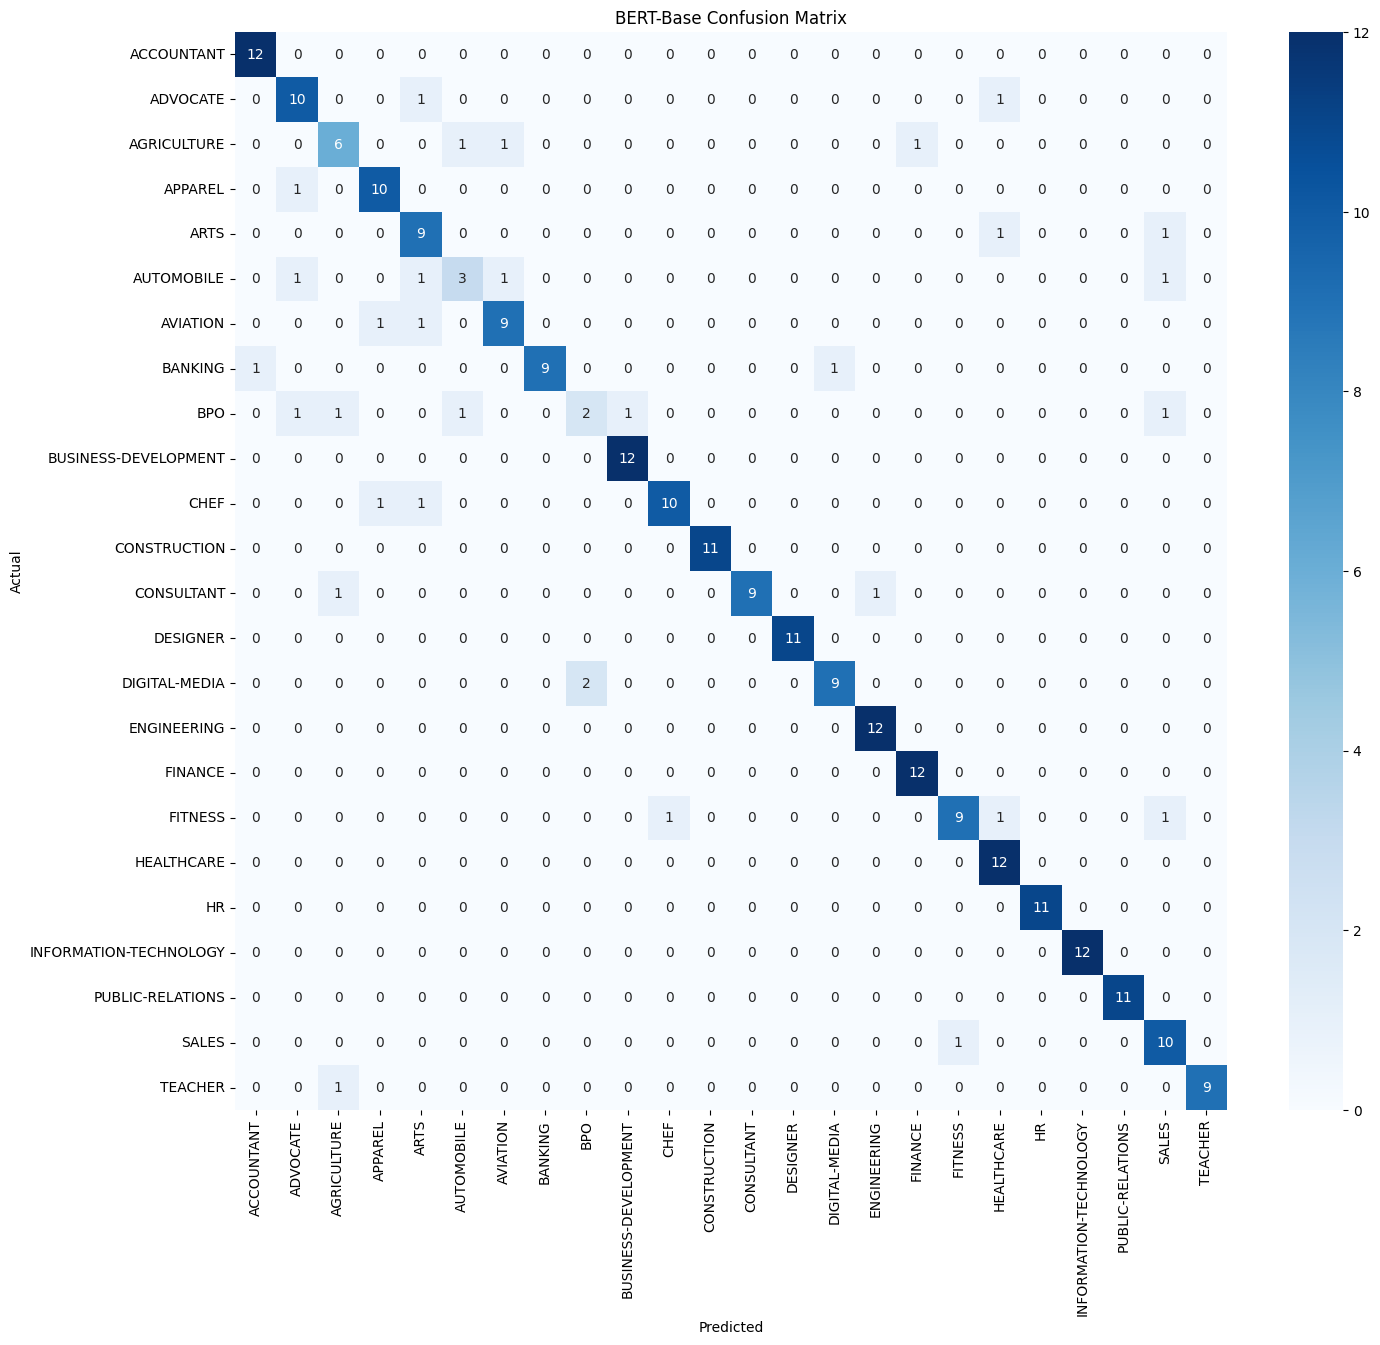

In [ ]:
"""
Generate BERT-Base evaluation report with classification metrics and confusion matrix.
"""
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def get_predictions(model, data_loader, device):
    """Generate predictions for all samples in the data loader."""
    model.eval()
    predictions = []
    real_values = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Predicting on CPU"):
            ids = batch['ids'].to(device)
            mask = batch['mask'].to(device)
            targets = batch['targets'].to(device)

            outputs = model(input_ids=ids, attention_mask=mask, labels=targets)
            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)

            predictions.extend(preds.cpu().numpy())
            real_values.extend(targets.cpu().numpy())

    return np.array(predictions), np.array(real_values)

print("📊 Generating BERT-Base Evaluation Report...")
y_pred, y_test = get_predictions(model, val_loader, device)

class_names = [k for k, v in sorted(category_map.items(), key=lambda item: item[1])]

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('BERT-Base Confusion Matrix')
plt.show()

In [ ]:
"""
Evaluate BERT-Base model on the final test set and report metrics.
"""
from tqdm import tqdm

print("🧪 Running BERT-Base Final Test Set Evaluation...")

model.eval()
test_loss = 0
test_correct = 0
test_total = 0

with torch.no_grad():
    progress_bar = tqdm(test_loader, desc="Testing BERT-Base", unit="batch")

    for batch in progress_bar:
        ids = batch['ids'].to(device)
        mask = batch['mask'].to(device)
        targets = batch['targets'].to(device)

        outputs = model(ids, attention_mask=mask, labels=targets)

        loss = outputs.loss
        logits = outputs.logits

        test_loss += loss.item()

        _, preds = torch.max(logits, 1)
        test_correct += torch.sum(preds == targets).item()
        test_total += targets.size(0)

        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

bert_test_acc = test_correct / test_total
bert_test_loss = test_loss / len(test_loader)

test_acc = bert_test_acc
test_loss = bert_test_loss

print(f"\n" + "="*30)
print(f"FINAL BERT TEST RESULTS")
print(f"="*30)
print(f"Test Loss: {bert_test_loss:.4f}")
print(f"Test Accuracy: {bert_test_acc:.4f}")
print(f"="*30)

🧪 Running BERT-Base Final Test Set Evaluation...


Testing BERT-Base: 100%|██████████| 17/17 [10:02<00:00, 35.43s/batch, loss=0.0663]


FINAL BERT TEST RESULTS
Test Loss: 0.6263
Test Accuracy: 0.8435


In [ ]:
"""
Demonstrate BERT-Base inference on sample test resumes.
"""
def predict_resume(text, model, tokenizer, device, category_map):
    """Predict the job category for a given resume text."""
    id_to_category = {v: k for k, v in category_map.items()}

    inputs = tokenizer.encode_plus(
        text,
        None,
        add_special_tokens=True,
        max_length=512,
        padding='max_length',
        return_token_type_ids=False,
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    ids = inputs['input_ids'].to(device)
    mask = inputs['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(ids, attention_mask=mask)
        _, prediction = torch.max(outputs.logits, dim=1)

    predicted_id = prediction.item()
    return id_to_category[predicted_id]

print("🤖 BERT Inference ready.")
print("Example Prediction on first 10 Test samples:")
for i in range(10):
    print(f"Testing for resume {test_df.index[i]}")
    sample_text = test_df['cleaned_text'].iloc[i]
    predicted_label = predict_resume(sample_text, model, tokenizer, device, category_map)
    actual_label = [k for k, v in category_map.items() if v == test_df['Category_Label'].iloc[i]][0]

    print(f"Actual: {actual_label}")
    print(f"Predicted: {predicted_label}")

🤖 BERT Inference ready.
Example Prediction on first 10 Test samples:
Testing for resume 465
Actual: ADVOCATE
Predicted: ADVOCATE
Testing for resume 165
Actual: DESIGNER
Predicted: DESIGNER
Testing for resume 651
Actual: BUSINESS-DEVELOPMENT
Predicted: BUSINESS-DEVELOPMENT
Testing for resume 968
Actual: AGRICULTURE
Predicted: SALES
Testing for resume 1224
Actual: CONSULTANT
Predicted: CONSULTANT
Testing for resume 2095
Actual: CONSTRUCTION
Predicted: CONSTRUCTION
Testing for resume 890
Actual: FITNESS
Predicted: DIGITAL-MEDIA
Testing for resume 2133
Actual: CONSTRUCTION
Predicted: CONSTRUCTION
Testing for resume 2385
Actual: BANKING
Predicted: BANKING
Testing for resume 2176
Actual: PUBLIC-RELATIONS
Predicted: PUBLIC-RELATIONS


In [ ]:
"""
Save detailed BERT-Base metrics to JSON for model comparison.
"""
import os
import json
import pandas as pd
from sklearn.metrics import classification_report

MODEL_NAME = "BERT-Base"

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data"
METRICS_DIR = os.path.join(BASE_PATH, "detailed_model_metrics")

if not os.path.exists(METRICS_DIR):
    os.makedirs(METRICS_DIR)

print(f"💾 Saving DETAILED metrics for {MODEL_NAME}...")

required_vars = ['y_test', 'y_pred', 'test_acc', 'test_loss', 'category_map']
missing = [v for v in required_vars if v not in locals()]
if missing:
    print(f"❌ Error: Missing variables {missing}. Please run Cell 6 and Cell 7 first!")
else:
    class_names = [k for k, v in sorted(category_map.items(), key=lambda item: item[1])]

    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        output_dict=True
    )

    final_data = {
        "model_name": MODEL_NAME,
        "test_results": {
            "accuracy": float(test_acc),
            "loss": float(test_loss)
        },
        "classification_report": report_dict,
        "parameters": "66M" if "Distil" in MODEL_NAME else ("110M" if "Base" in MODEL_NAME else "14M")
    }

    filename = f"{MODEL_NAME}_detailed_metrics.json"
    save_path = os.path.join(METRICS_DIR, filename)

    with open(save_path, 'w') as f:
        json.dump(final_data, f, indent=4)

    print(f"✅ Success! Detailed report saved to:")
    print(f"   📂 {save_path}")
    print(f"   📊 Contains: Test Acc ({test_acc:.4f}), Test Loss ({test_loss:.4f}), and F1-scores for {len(class_names)} categories.")

💾 Saving DETAILED metrics for BERT-Base...
✅ Success! Detailed report saved to:
   📂 /content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data/detailed_model_metrics/BERT-Base_detailed_metrics.json
   📊 Contains: Test Acc (0.8435), Test Loss (0.6263), and F1-scores for 24 categories.


# Final comparison


In [ ]:
"""
Load saved metrics from all three models and aggregate them into DataFrames
for comprehensive comparison analysis.
"""
import pandas as pd
import json
import os
import seaborn as sns
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/Conversational_AI_ADS_Resume_Project/data"
METRICS_DIR = os.path.join(BASE_PATH, "detailed_model_metrics")

summary_data = []
category_data = []

if os.path.exists(METRICS_DIR):
    files = [f for f in os.listdir(METRICS_DIR) if f.endswith('_detailed_metrics.json')]

    if not files:
        print("❌ No JSON metric files found. Did you run the 'New Step 9' for each model?")
    else:
        print(f"📂 Found {len(files)} model reports. Loading...")

        for file in files:
            with open(os.path.join(METRICS_DIR, file), 'r') as f:
                data = json.load(f)

                summary_data.append({
                    "Model": data['model_name'],
                    "Test Accuracy": data['test_results']['accuracy'],
                    "Test Loss": data['test_results']['loss'],
                    "Parameters": data['parameters'],
                    "Macro F1": data['classification_report']['macro avg']['f1-score'],
                    "Weighted F1": data['classification_report']['weighted avg']['f1-score']
                })

                for cat, metrics in data['classification_report'].items():
                    if cat not in ['accuracy', 'macro avg', 'weighted avg']:
                        category_data.append({
                            "Model": data['model_name'],
                            "Category": cat,
                            "F1-Score": metrics['f1-score'],
                            "Precision": metrics['precision'],
                            "Recall": metrics['recall']
                        })

        df_summary = pd.DataFrame(summary_data).sort_values(by="Test Accuracy", ascending=False)
        df_category = pd.DataFrame(category_data)

        print("✅ Data Loaded Successfully.")
else:
    print(f"❌ Directory not found: {METRICS_DIR}")

📂 Found 3 model reports. Loading...
✅ Data Loaded Successfully.


In [ ]:
"""
Display styled leaderboard table ranking all models by test accuracy.
"""
if 'df_summary' in locals() and not df_summary.empty:
    print("\n🏆 EXECUTIVE MODEL LEADERBOARD 🏆")

    format_dict = {
        'Test Accuracy': '{:.2%}',
        'Macro F1': '{:.2%}',
        'Weighted F1': '{:.2%}',
        'Test Loss': '{:.4f}'
    }

    styled = df_summary.style.background_gradient(
        subset=['Test Accuracy', 'Macro F1'], cmap='Greens'
    ).background_gradient(
        subset=['Test Loss'], cmap='Reds_r'
    ).format(format_dict).hide(axis="index")

    display(styled)


🏆 EXECUTIVE MODEL LEADERBOARD 🏆


Model,Test Accuracy,Test Loss,Parameters,Macro F1,Weighted F1
BERT-Base,84.35%,0.6263,110M,85.79%,87.39%
DistilBERT,83.59%,0.6854,66M,85.86%,86.85%
ELECTRA-Small,82.06%,0.8582,14M,82.96%,84.49%


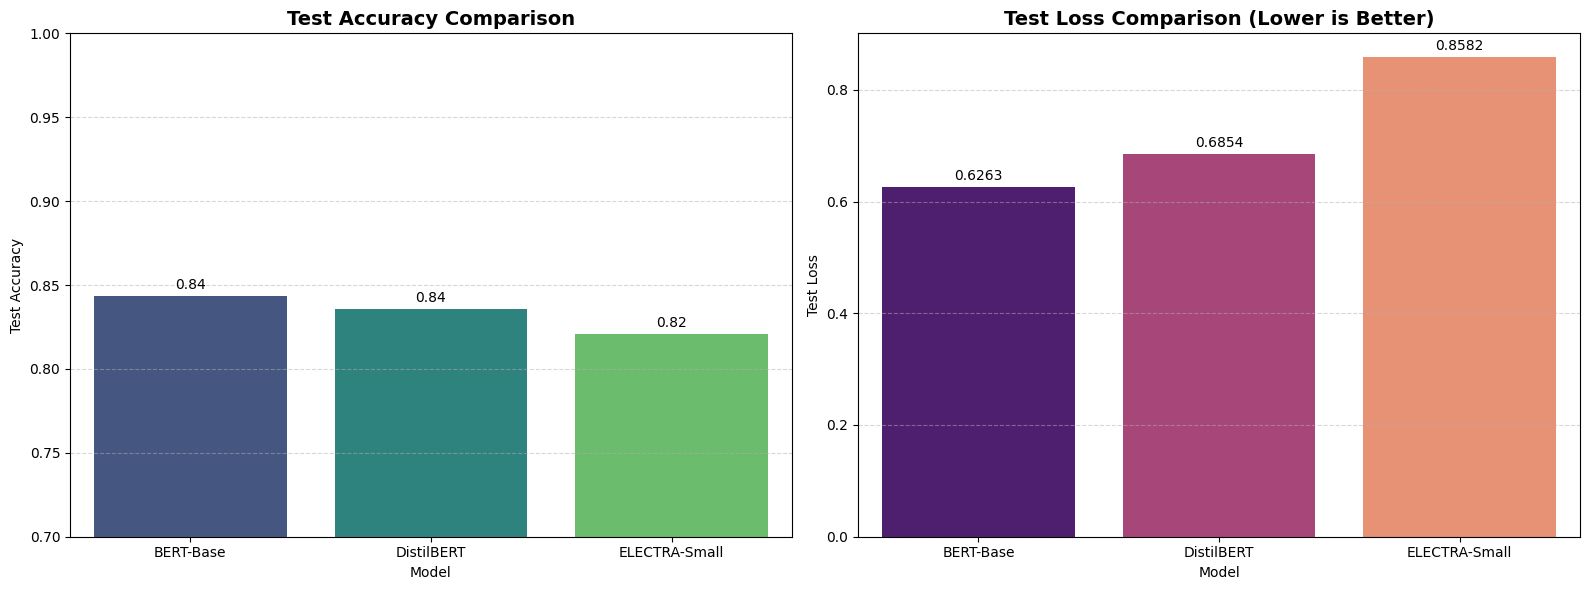

In [ ]:
"""
Create side-by-side bar charts comparing test accuracy and loss across all models.
"""
if 'df_summary' in locals() and not df_summary.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(data=df_summary, x="Model", y="Test Accuracy", hue="Model", palette="viridis", ax=axes[0], legend=False)
    axes[0].set_ylim(0.7, 1.0)
    axes[0].set_title("Test Accuracy Comparison", fontsize=14, weight='bold')
    axes[0].grid(axis='y', linestyle='--', alpha=0.5)
    for container in axes[0].containers:
        axes[0].bar_label(container, fmt='%.2f', padding=3)

    sns.barplot(data=df_summary, x="Model", y="Test Loss", hue="Model", palette="magma", ax=axes[1], legend=False)
    axes[1].set_title("Test Loss Comparison (Lower is Better)", fontsize=14, weight='bold')
    axes[1].grid(axis='y', linestyle='--', alpha=0.5)
    for container in axes[1].containers:
        axes[1].bar_label(container, fmt='%.4f', padding=3)

    plt.tight_layout()
    plt.show()

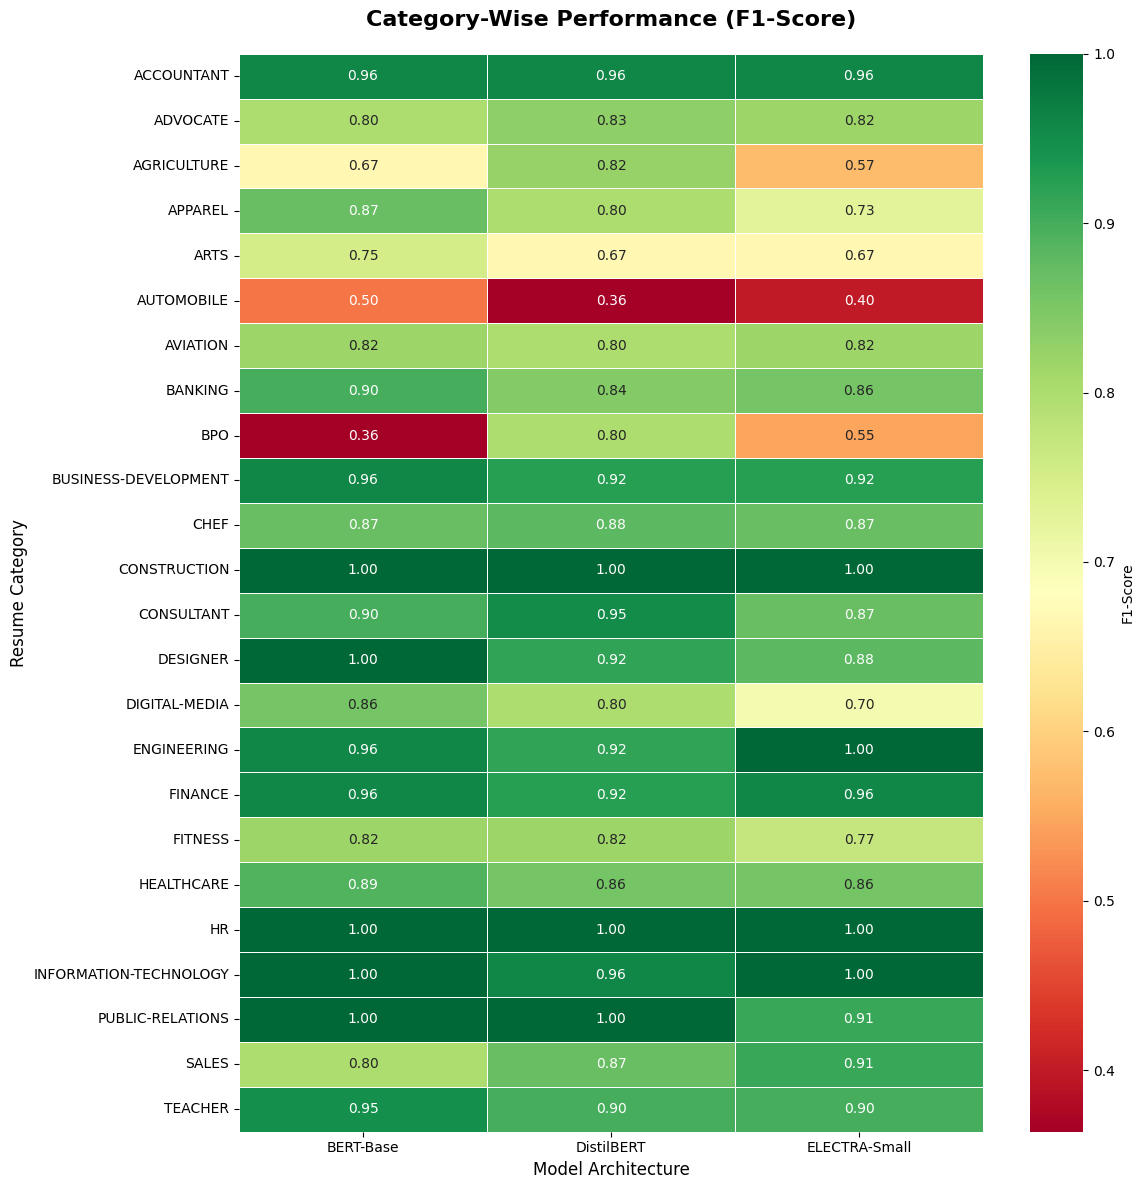

In [ ]:
"""
Generate heatmap showing per-category F1-scores for each model,
enabling identification of category-specific performance patterns.
"""
if 'df_category' in locals() and not df_category.empty:
    plt.figure(figsize=(12, 14))

    heatmap_data = df_category.pivot(index="Category", columns="Model", values="F1-Score")
    heatmap_data = heatmap_data.sort_index()

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        linewidths=.5,
        cbar_kws={'label': 'F1-Score'}
    )

    plt.title("Category-Wise Performance (F1-Score)", fontsize=16, weight='bold', pad=20)
    plt.ylabel("Resume Category", fontsize=12)
    plt.xlabel("Model Architecture", fontsize=12)
    plt.show()

In [ ]:
"""
Generate automated analysis report summarizing best performing models
and their key characteristics.
"""
if 'df_summary' in locals() and not df_summary.empty:
    best_acc = df_summary.iloc[0]
    best_f1 = df_summary.sort_values(by="Macro F1", ascending=False).iloc[0]

    print("📝 AUTOMATED ANALYSIS REPORT")
    print("=" * 50)
    print(f"1. OVERALL WINNER: {best_acc['Model']}")
    print(f"   - Achieved the highest Test Accuracy of {best_acc['Test Accuracy']:.2%}.")
    print(f"   - Achieved a Test Loss of {best_acc['Test Loss']:.4f}.")

    print(f"\n2. CATEGORY CONSISTENCY: {best_f1['Model']}")
    print(f"   - Achieved the highest Macro F1-Score of {best_f1['Macro F1']:.2%}.")
    print(f"   - This indicates {best_f1['Model']} is the most balanced across all job categories,")
    print(f"     performing well even on minority classes.")

    print("\n3. ARCHITECTURAL COMPARISON")
    for index, row in df_summary.iterrows():
        print(f"   - {row['Model']} ({row['Parameters']}): Accuracy={row['Test Accuracy']:.2%}, Loss={row['Test Loss']:.4f}")

    print("=" * 50)

📝 AUTOMATED ANALYSIS REPORT
1. OVERALL WINNER: BERT-Base
   - Achieved the highest Test Accuracy of 84.35%.
   - Achieved a Test Loss of 0.6263.

2. CATEGORY CONSISTENCY: DistilBERT
   - Achieved the highest Macro F1-Score of 85.86%.
   - This indicates DistilBERT is the most balanced across all job categories,
     performing well even on minority classes.

3. ARCHITECTURAL COMPARISON
   - BERT-Base (110M): Accuracy=84.35%, Loss=0.6263
   - DistilBERT (66M): Accuracy=83.59%, Loss=0.6854
   - ELECTRA-Small (14M): Accuracy=82.06%, Loss=0.8582
